In [1]:
import pandas as pd

df = pd.read_csv('Reviews.csv')

df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1.0,1.0,5.0,1.303862e+09,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0.0,0.0,1.0,1.346976e+09,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1.0,1.0,4.0,1.219018e+09,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3.0,3.0,2.0,1.307923e+09,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0.0,0.0,5.0,1.350778e+09,Great taffy,Great taffy at a great price. There was a wid...


In [2]:
import pandas as pd

df = pd.read_csv('Reviews.csv')

print(df.shape)

(10100, 10)


In [3]:
df.head()


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1.0,1.0,5.0,1.303862e+09,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0.0,0.0,1.0,1.346976e+09,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1.0,1.0,4.0,1.219018e+09,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3.0,3.0,2.0,1.307923e+09,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0.0,0.0,5.0,1.350778e+09,Great taffy,Great taffy at a great price. There was a wid...


In [4]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

In [5]:
df.isnull().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,1
HelpfulnessNumerator,1
HelpfulnessDenominator,1
Score,1
Time,1
Summary,1
Text,2


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10100 entries, 0 to 10099
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Id                      10100 non-null  int64  
 1   ProductId               10100 non-null  object 
 2   UserId                  10100 non-null  object 
 3   ProfileName             10099 non-null  object 
 4   HelpfulnessNumerator    10099 non-null  float64
 5   HelpfulnessDenominator  10099 non-null  float64
 6   Score                   10099 non-null  float64
 7   Time                    10099 non-null  float64
 8   Summary                 10099 non-null  object 
 9   Text                    10098 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 789.2+ KB


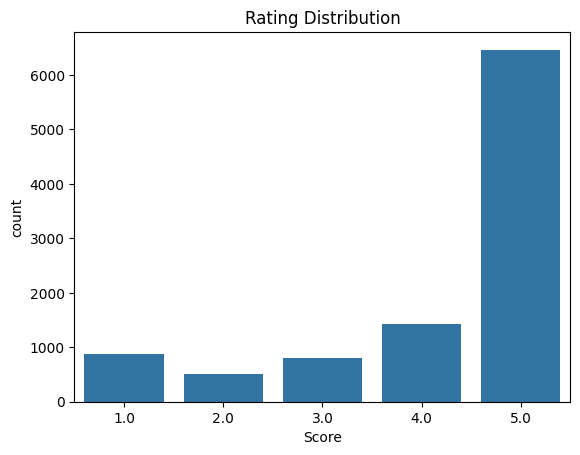

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Score', data=df)

plt.title('Rating Distribution')
plt.show()

In [9]:
print("Unique Users:", df['UserId'].nunique())

print("Unique Products:", df['ProductId'].nunique())

Unique Users: 9507
Unique Products: 1495


In [10]:
ratings = df[['UserId', 'ProductId', 'Score']]

ratings.head()

,UserId,ProductId,Score
0,A3SGXH7AUHU8GW,B001E4KFG0,5.0
1,A1D87F6ZCVE5NK,B00813GRG4,1.0
2,ABXLMWJIXXAIN,B000LQOCH0,4.0
3,A395BORC6FGVXV,B000UA0QIQ,2.0
4,A1UQRSCLF8GW1T,B006K2ZZ7K,5.0


In [11]:
product_ratings = ratings.groupby('ProductId')['Score'].count()

product_ratings.sort_values(ascending=False).head(10)

,Score
ProductId,
B005K4Q1VI,324
B001RVFDOO,305
B0045XE32E,282
B004391DK0,232
B000G6RYNE,217
B000255OIG,173
B007TJGZ5E,172
B00139TT72,159
B0032BXUJM,148


In [12]:
user_counts = ratings['UserId'].value_counts()

active_users = user_counts[user_counts >= 5].index

ratings_filtered = ratings[
    ratings['UserId'].isin(active_users)
]

ratings_filtered.shape

(68, 3)

In [13]:
user_product_matrix = ratings_filtered.pivot_table(
    index='UserId',
    columns='ProductId',
    values='Score'
)

user_product_matrix.head()

ProductId,B000255OIG,B0004MZVIA,B000ARTNR4,B000AY9U20,B000BHREYW,B000ER6YO0,B000F9XBD4,B000F9Z1WI,B000FDKQCY,B000G6RYNE,...,B004WMB132,B004YPV15A,B00503DP0O,B0052OI128,B0054TWQ2C,B005K4Q1VI,B005TY2REE,B007J6GGII,B007TJGZ5E,B008YAXFWI
UserId,,,,,,,,,,,,,,,,,,,,,
A2MUGFV2TDQ47K,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A2R6RA8FRBS608,NaN,5.0,NaN,NaN,NaN,NaN,5.0,5.0,NaN,NaN,...,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN
A2TN9C5E4A0I3F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A31N6KB160O508,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,5.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A3NHUQ33CFH3VM,NaN,NaN,2.0,NaN,NaN,3.25,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
!pip install scikit-surprise

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 56.7 MB/s eta 0:00:00


In [15]:
from surprise import Dataset
from surprise import Reader
from surprise import SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

In [16]:
reader = Reader(rating_scale=(1,5))

data = Dataset.load_from_df(
    ratings_filtered[['UserId','ProductId','Score']],
    reader
)

In [17]:
trainset, testset = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

In [18]:
svd = SVD()

svd.fit(trainset)

In [19]:
predictions = svd.test(testset)

In [20]:
accuracy.rmse(predictions)

RMSE: 0.8233


np.float64(0.8233256038066556)

In [21]:
user_id = ratings_filtered['UserId'].iloc[0]

user_id

'A2MUGFV2TDQ47K'

In [22]:
products = ratings_filtered['ProductId'].unique()

recommendations = []

for product in products:
    pred = svd.predict(user_id, product)
    recommendations.append(
        (product, pred.est)
    )

recommendations = sorted(
    recommendations,
    key=lambda x:x[1],
    reverse=True
)

recommendations[:10]

[('B0036FOV2O', np.float64(4.448542612440825)),
 ('B001GVISJM', np.float64(4.445541609377004)),
 ('B00139TT72', np.float64(4.39678246407951)),
 ('B007TJGZ5E', np.float64(4.360496619408675)),
 ('B0052OI128', np.float64(4.319915749292848)),
 ('B001G2F5R4', np.float64(4.272628137644767)),
 ('B000VSDFRG', np.float64(4.267939754788048)),
 ('B005TY2REE', np.float64(4.25347737977395)),
 ('B000255OIG', np.float64(4.253166395013639)),
 ('B000FDKQCY', np.float64(4.242016944714056))]

In [23]:
from surprise.accuracy import rmse

rmse(predictions)

RMSE: 0.8233


np.float64(0.8233256038066556)

In [24]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 47.5 MB/s eta 0:00:00


In [25]:
%%writefile app.py

import streamlit as st
import pandas as pd
from surprise import Dataset, Reader, SVD

st.title("🛒 E-Commerce Product Recommendation System")

# Load dataset
df = pd.read_csv("Reviews.csv")

ratings = df[['UserId','ProductId','Score']]

# Filter active users
user_counts = ratings['UserId'].value_counts()
active_users = user_counts[user_counts >= 5].index

ratings_filtered = ratings[
    ratings['UserId'].isin(active_users)
]

# Train SVD
reader = Reader(rating_scale=(1,5))

data = Dataset.load_from_df(
    ratings_filtered[['UserId','ProductId','Score']],
    reader
)

trainset = data.build_full_trainset()

model = SVD()
model.fit(trainset)

# User selection
user_id = st.selectbox(
    "Select User",
    ratings_filtered['UserId'].unique()
)

if st.button("Recommend Products"):

    products = ratings_filtered['ProductId'].unique()

    recommendations = []

    for product in products:
        pred = model.predict(user_id, product)
        recommendations.append(
            (product, pred.est)
        )

    recommendations = sorted(
        recommendations,
        key=lambda x:x[1],
        reverse=True
    )

    st.subheader("Top 10 Recommended Products")

    for product, score in recommendations[:10]:
        st.write(
            f"Product: {product} | Predicted Rating: {score:.2f}"
        )

Writing app.py


In [28]:
from pyngrok import ngrok

ngrok.set_auth_token("3EtErV0MhKpdqjdef8iAzSS2KlF_5ToaK2uDLxQuCEnbo85Pq")

In [29]:
public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://requisite-stray-plural.ngrok-free.dev" -> "http://localhost:8501"


In [31]:
!streamlit run app.py



2026-06-14 14:49:52.486 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.21.76.139:8501

  Stopping...


In [32]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://requisite-stray-plural.ngrok-free.dev" -> "http://localhost:8501"


In [33]:
!ps aux | grep streamlit

root        2821  0.0  0.0   7372  3476 ?        S    14:53   0:00 /bin/bash -c ps aux | grep streamlit
root        2823  0.0  0.0   6480  2376 ?        S    14:53   0:00 grep streamlit


In [34]:
!streamlit run app.py

2026-06-14 14:53:55.734 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.21.76.139:8501

  Stopping...
  Stopping...


In [35]:
!streamlit run app.py > logs.txt 2>&1 &

In [36]:
!cat logs.txt

In [37]:
!ps aux | grep streamlit

root        2884  0.0  0.2  42464 31580 ?        R    14:54   0:00 /usr/bin/python3 /usr/local/bin/streamlit run app.py
root        2890  0.0  0.0   7372  3444 ?        S    14:54   0:00 /bin/bash -c ps aux | grep streamlit
root        2892  0.0  0.0   6480  2544 ?        S    14:54   0:00 grep streamlit


In [38]:
!cat logs.txt

In [39]:
from pyngrok import ngrok

ngrok.kill()  # optional

public_url = ngrok.connect(8502)

print(public_url)

NgrokTunnel: "https://requisite-stray-plural.ngrok-free.dev" -> "http://localhost:8502"


In [40]:
!pip install scikit-surprise

In [41]:
!pkill -f streamlit

In [42]:
from surprise import Dataset, Reader, SVD

print("Surprise installed successfully")

Surprise installed successfully


In [43]:
!streamlit run app.py > logs.txt 2>&1 &

In [44]:
from pyngrok import ngrok

ngrok.kill()

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://requisite-stray-plural.ngrok-free.dev" -> "http://localhost:8501"


In [45]:
!ls -lh /content

total 308M
-rw-r--r-- 1 root root 1.3K Jun 14 14:48 app.py
-rw-r--r-- 1 root root   85 Jun 14 14:54 logs.txt
-rw-r--r-- 1 root root 307M Jun 14 14:53 Reviews.csv
drwxr-xr-x 1 root root 4.0K Jun  4 13:32 sample_data


In [46]:
!ls -lh /content

total 308M
-rw-r--r-- 1 root root 1.3K Jun 14 14:48 app.py
-rw-r--r-- 1 root root   85 Jun 14 14:54 logs.txt
-rw-r--r-- 1 root root 307M Jun 14 14:53 Reviews.csv
drwxr-xr-x 1 root root 4.0K Jun  4 13:32 sample_data


In [47]:
!pkill -f streamlit

In [48]:
!streamlit run app.py > logs.txt 2>&1 &

In [50]:
!tail -50 logs.txt



2026-06-14 14:54:50.115 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.21.76.139:8501



In [49]:
from pyngrok import ngrok

ngrok.kill()

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://requisite-stray-plural.ngrok-free.dev" -> "http://localhost:8501"


In [51]:
import pandas as pd

df = pd.read_csv(
    "Reviews.csv",
    engine="python",
    on_bad_lines="skip"
)

print(df.shape)

(600347, 10)


In [52]:
!pkill -f streamlit

In [53]:
!streamlit run app.py > logs.txt 2>&1 &

In [54]:
!tail -20 logs.txt



2026-06-14 14:55:15.947 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.21.76.139:8501



In [55]:
!tail -50 logs.txt



2026-06-14 14:55:15.947 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.21.76.139:8501



In [56]:
from pyngrok import ngrok

ngrok.kill()

public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://requisite-stray-plural.ngrok-free.dev" -> "http://localhost:8501"


In [57]:
from sklearn.metrics import ndcg_score
import numpy as np

In [58]:
relevant_items = {}

for user in ratings_filtered['UserId'].unique():

    user_data = ratings_filtered[ratings_filtered['UserId'] == user]

    relevant_items[user] = set(
        user_data[user_data['Score'] >= 4]['ProductId']
    )

print("Users processed:", len(relevant_items))

Users processed: 9


In [59]:
ratings = df[['UserId', 'ProductId', 'Score']]

user_counts = ratings['UserId'].value_counts()

active_users = user_counts[user_counts >= 5].index

ratings_filtered = ratings[
    ratings['UserId'].isin(active_users)
]

print(ratings_filtered.shape)

(275746, 3)


In [60]:
ratings_filtered.head()

,UserId,ProductId,Score
11,A2725IB4YY9JEB,B0009XLVG0,5
13,A18ECVX2RJ7HUE,B001GVISJM,4
14,A2MUGFV2TDQ47K,B001GVISJM,5
18,A2A9X58G2GTBLP,B001GVISJM,5
23,AJ613OLZZUG7V,B001GVISJM,5


In [62]:
from surprise import Dataset, Reader, SVD

In [64]:
svd = SVD()

svd.fit(trainset)

print("SVD Model Trained")

SVD Model Trained


In [65]:
sample_users = ratings_filtered['UserId'].unique()[:100]

len(sample_users)

100

In [66]:
K = 10

recommended_items = {}

products = ratings_filtered['ProductId'].unique()

for user in sample_users:

    predictions = []

    for product in products:

        pred = svd.predict(user, product)

        predictions.append((product, pred.est))

    predictions.sort(
        key=lambda x: x[1],
        reverse=True
    )

    recommended_items[user] = [
        p[0] for p in predictions[:K]
    ]

print("Done")

Done


from sklearn.metrics import ndcg_score

ndcg_scores = []

for user in sample_users:

    y_true = []
    y_score = []

    relevant = relevant_items[user]

    for product in recommended_items[user]:

        y_true.append(
            1 if product in relevant else 0
        )

        y_score.append(
            svd.predict(user, product).est
        )

    if sum(y_true) > 0:

        ndcg_scores.append(
            ndcg_score(
                [y_true],
                [y_score]
            )
        )

avg_ndcg = np.mean(
    ndcg_scores
)

print("NDCG@10 =", avg_ndcg)

In [72]:
sample_users = list(relevant_items.keys())[:100]

print(len(sample_users))

0


In [74]:
print("Relevant users:", len(relevant_items))
print("Recommended users:", len(recommended_items))

Relevant users: 0
Recommended users: 100


In [77]:
print(ratings_filtered['Score'].dtype)

float64


In [78]:
ratings_filtered = ratings_filtered.copy()

ratings_filtered['Score'] = pd.to_numeric(
    ratings_filtered['Score'],
    errors='coerce'
)

In [79]:
print(ratings_filtered['Score'].dtype)

float64


In [86]:
relevant_items = (
    ratings_filtered[ratings_filtered['Score'] >= 4]
    .groupby('UserId')['ProductId']
    .apply(set)
    .to_dict()
)

print("Users processed:", len(relevant_items))

Users processed: 22212


In [87]:
print(len(relevant_items))
print(len(recommended_items))

22212
100


In [89]:
print("Relevant users:", len(relevant_items))
print("Recommended users:", len(recommended_items))

common_users = set(relevant_items.keys()) & set(recommended_items.keys())

print("Common users:", len(common_users))

Relevant users: 22212
Recommended users: 100
Common users: 97


In [90]:
sample_users = list(
    set(relevant_items.keys()) &
    set(recommended_items.keys())
)

print(len(sample_users))

97


In [96]:
precision_scores = []

for user in sample_users:

    relevant = relevant_items[user]
    recommended = set(recommended_items[user])

    precision = len(recommended & relevant) / 10

    precision_scores.append(precision)

precision_at_10 = np.mean(precision_scores)

print("Precision@10 =", precision_at_10)

Precision@10 = 0.018556701030927835


In [92]:
list(recommended_items.keys())[:5]

['A2725IB4YY9JEB',
 'A18ECVX2RJ7HUE',
 'A2MUGFV2TDQ47K',
 'A2A9X58G2GTBLP',
 'AJ613OLZZUG7V']

In [93]:
list(relevant_items.keys())[:5]

['A1004703RC79J9',
 'A1007PT85CIPMD',
 'A100IC7JRCQDUD',
 'A100S1JQ5XK960',
 'A100UZGZNZ9ZYN']

In [94]:
recall_scores = []

for user in sample_users:

    relevant = relevant_items[user]
    recommended = set(recommended_items[user])

    recall = len(recommended & relevant) / len(relevant)

    recall_scores.append(recall)

recall_at_10 = np.mean(recall_scores)

print("Recall@10 =", recall_at_10)

Recall@10 = 0.012621022158762117


In [95]:
from sklearn.metrics import ndcg_score

ndcg_scores = []

for user in sample_users:

    relevant = relevant_items[user]

    y_true = []
    y_score = []

    for product in recommended_items[user]:

        y_true.append(
            1 if product in relevant else 0
        )

        y_score.append(
            svd.predict(user, product).est
        )

    if sum(y_true) > 0:

        ndcg_scores.append(
            ndcg_score(
                [y_true],
                [y_score]
            )
        )

avg_ndcg = np.mean(ndcg_scores)

print("NDCG@10 =", avg_ndcg)

NDCG@10 = 0.529985041305555
